# <span style="color:blue"><b>PROYECTO FINAL</b></span>

# <span style="color:blue"><b>Detección de Carteras Falsificadas mediante One-Class Classification</b></span>


#Integrantes
### ● Jesus Campos
### ● Marco Barrera
### ● Thomy Villanueva



In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!ls /content/drive

MyDrive


In [3]:
!ls /content/drive/MyDrive/VP_EF

 Autenticacion_Carteras__Metricas.ipynb   handbag_oneclass_efficientnet.h5
 chanel.zip				  handbag_oneclass_efficientnet.pth
 deep_svdd_resnet18.pth			  handbag.zip
'Demo de la Aplicacion.mp4'		  ocsvm_efficientnet.pkl
 descargas_lote_ordenado.7z		  oneclass_center.pt
 descargas_lote_ordenadov4.7z		  oneclass_metrics.npz
 fake_hard.zip				  oneclass_thresholds.json
 genuine.zip				  svdd_center.npy


In [5]:
import shutil
import os

SRC_ZIP = "/content/drive/MyDrive/VP_EF/chanel.zip"
DST_ZIP = "/content/chanel.zip"

print("Copiando ZIP a disco local...")
shutil.copy2(SRC_ZIP, DST_ZIP)
print("ZIP copiado a /content/")


Copiando ZIP a disco local...
ZIP copiado a /content/


In [6]:
import zipfile

with zipfile.ZipFile("/content/chanel.zip", "r") as z:
    for name in z.namelist()[:30]:
        print(name)

chanel/
chanel/fake/
chanel/fake/bag---2.55/
chanel/fake/bag---2.55/0104/
chanel/fake/bag---2.55/0104/0104_1.jpg
chanel/fake/bag---2.55/0104/0104_2.jpg
chanel/fake/bag---2.55/0104/0104_3.jpg
chanel/fake/bag---2.55/0104/0104_4.jpg
chanel/fake/bag---2.55/0105/
chanel/fake/bag---2.55/0105/0105_1.jpg
chanel/fake/bag---2.55/0105/0105_2.jpg
chanel/fake/bag---2.55/0105/0105_3.jpg
chanel/fake/bag---2.55/0105/0105_4.jpg
chanel/fake/bag---2.55/0105/0105_5.jpg
chanel/fake/bag---2.55/0106/
chanel/fake/bag---2.55/0106/0106_1.jpg
chanel/fake/bag---2.55/0106/0106_2.jpg
chanel/fake/bag---2.55/0107/
chanel/fake/bag---2.55/0107/0107_1.jpg
chanel/fake/bag---2.55/0107/0107_2.jpg
chanel/fake/bag---2.55/0107/0107_3.jpg
chanel/fake/bag---2.55/0107/0107_4.jpg
chanel/fake/bag---2.55/0107/0107_5.jpg
chanel/fake/bag---2.55/0107/0107_6.jpg
chanel/fake/bag---2.55/0107/0107_7.jpg
chanel/fake/bag---2.55/0107/0107_8.jpg
chanel/fake/bag---2.55/0107/0107_9.jpg
chanel/fake/bag---2.55/0108/
chanel/fake/bag---2.55/0108/01

In [7]:
import zipfile

EXTRACT_DIR = "/content/data"
os.makedirs(EXTRACT_DIR, exist_ok=True)

print("Descomprimiendo ZIP en /content/data...")
with zipfile.ZipFile(DST_ZIP, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_DIR)

print("Dataset descomprimido en /content/data")

Descomprimiendo ZIP en /content/data...
Dataset descomprimido en /content/data


In [9]:
!ls /content/data/chanel

fake  genuine


### <span style="color:#7b1e3a"><b>Split 70/15/15</b></span>

Se divide el dataset en 70% para entrenamiento del modelo, 15% para validación durante el ajuste y 15% para prueba final, garantizando una evaluación objetiva del rendimiento.


In [10]:
import os
import numpy as np
from sklearn.model_selection import GroupShuffleSplit

BASE_DIR = "/content/data/chanel"

data = []

for label_name in ["genuine", "fake"]:
    label = 1 if label_name == "genuine" else 0
    label_path = os.path.join(BASE_DIR, label_name)

    for bag_type in os.listdir(label_path):
        bag_path = os.path.join(label_path, bag_type)

        for group in os.listdir(bag_path):
            group_path = os.path.join(bag_path, group)

            for img in os.listdir(group_path):
                img_path = os.path.join(group_path, img)
                data.append((img_path, label, group))

data = np.array(data)

X = data[:, 0]
y = data[:, 1].astype(int)
groups = data[:, 2]

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss.split(X, y, groups))

X_train, y_train = X[train_idx], y[train_idx]
groups_train = groups[train_idx]

X_temp, y_temp = X[temp_idx], y[temp_idx]
groups_temp = groups[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(len(X_train), len(X_val), len(X_test))

10720 2451 2270


In [20]:
from PIL import Image
import numpy as np

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return True
    except:
        return False

def clean_dataset(X, y):
    valid_X = []
    valid_y = []
    invalid = []

    for path, label in zip(X, y):
        if is_valid_image(path):
            valid_X.append(path)
            valid_y.append(label)
        else:
            invalid.append(path)

    return np.array(valid_X), np.array(valid_y), invalid

X_train, y_train, invalid_train = clean_dataset(X_train, y_train)
X_val, y_val, invalid_val = clean_dataset(X_val, y_val)
X_test, y_test, invalid_test = clean_dataset(X_test, y_test)

print("Invalid train:", len(invalid_train))
print("Invalid val:", len(invalid_val))
print("Invalid test:", len(invalid_test))

print(invalid_train[:10])
print(invalid_val[:10])
print(invalid_test[:10])

### <span style="color:#7b1e3a"><b>Cargar y preparar las imágenes</b></span>  
(data pipeline)

In [21]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    img = tf.cast(img, tf.float32)
    img = tf.keras.applications.efficientnet.preprocess_input(img)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### <span style="color:#800020"><b>Entrenamiento del Modelo para Autenticación de Carteras</b></span>

Se entrena un modelo de clasificación binaria para distinguir entre carteras genuinas y falsas usando EfficientNetB0.
Se utiliza validación y early stopping para mejorar la generalización y evitar sobreajuste.

In [22]:
import tensorflow as tf

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(224, 224, 3)
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 62s 123ms/step - accuracy: 0.8319 - loss: 0.4476 - val_accuracy: 0.3395 - val_loss: 1.1750
Epoch 2/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.7758 - loss: 0.4911 - val_accuracy: 0.4659 - val_loss: 0.9351
Epoch 3/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8099 - loss: 0.4313 - val_accuracy: 0.5483 - val_loss: 0.8260
Epoch 4/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 56ms/step - accuracy: 0.8312 - loss: 0.3900 - val_accuracy: 0.6055 - val_loss: 0.7456
Epoch 5/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8502 - loss: 0.3593 - val_accuracy: 0.6455 - val_loss: 0.6957
Epoch 6/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8563 - loss: 0.3379 - val_accuracy: 0.6789 - val_loss: 0.6490
Epoch 7/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8671 - loss: 0.3186 - val_accuracy: 0.7026 - val_loss: 0.6208
Epoch 8/20
335/335 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.8783 - loss: 0.3021 -

### <span style="color:#800020"><b>Evaluación del Modelo en el Conjunto de Prueba</b></span>


In [23]:
test_loss, test_acc = model.evaluate(test_ds)

print("Test loss:", test_loss)
print("Test accuracy:", test_acc)


71/71 ━━━━━━━━━━━━━━━━━━━━ 22s 310ms/step - accuracy: 0.8200 - loss: 0.3892
Test loss: 0.3891873061656952
Test accuracy: 0.8200264573097229


### <span style="color:#800020"><b>Guardar modelo en Google Drive</b></span>



In [26]:
from google.colab import drive
drive.mount('/content/drive')

model.save("/content/drive/MyDrive/VP_EF/modelo_autenticacion.keras")
model.save("/content/drive/MyDrive/VP_EF/modelo_autenticacion.h5")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### <span style="color:#800020"><b>Gráficas de Entrenamiento del Modelo</b></span>


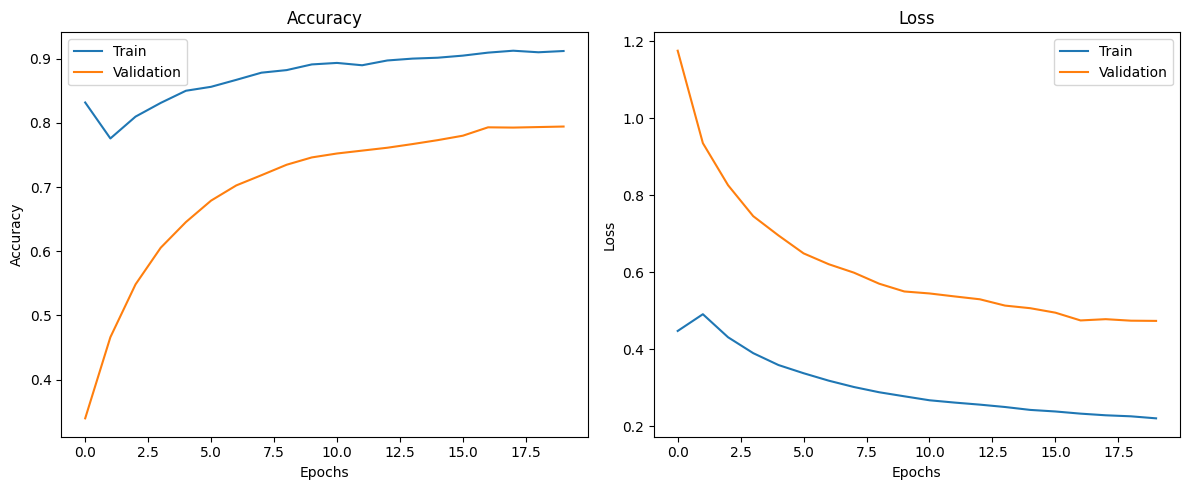

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/graficas_entrenamiento.png")
plt.show()


### <span style="color:#800020"><b>Matriz de Confusión del Modelo</b></span>



1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━

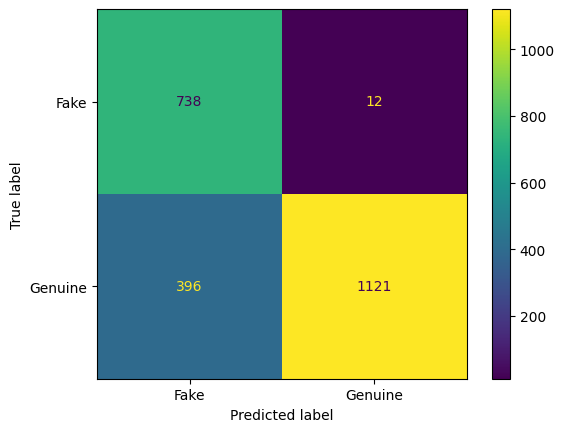

In [28]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images)
    classes = np.argmax(preds, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(classes)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake","Genuine"])
disp.plot()


### <span style="color:#800020"><b>Reporte de Clasificación</b></span>



In [29]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=["Fake","Genuine"]))



              precision    recall  f1-score   support

        Fake       0.65      0.98      0.78       750
     Genuine       0.99      0.74      0.85      1517

    accuracy                           0.82      2267
   macro avg       0.82      0.86      0.81      2267
weighted avg       0.88      0.82      0.83      2267

